# FinBERT Cross-Dataset Evaluation: Distribution Shift in Practice

**Chapter 10: From Text to Features - The Transformer Breakthrough**
**Section Reference**: See Section 10.4 for Transformers and distribution shift

**Docker image**: `ml4t-gpu`

> **GPU recommended**: ProsusAI/finbert is run as inference over ~8K headlines.
> A GPU brings the notebook to ~1 minute end-to-end; on CPU it takes 5–10×
> longer. For GPU acceleration:
> ```bash
> docker compose run --rm ml4t-gpu python 10_text_feature_engineering/06_finbert_cross_dataset.py
> ```

## Purpose
This notebook demonstrates distribution shift by evaluating ProsusAI/finbert
(trained on Financial PhraseBank) on the FinMarBa dataset. Both datasets use
the same labels (positive/negative/neutral), but differ in text domain:
- Financial PhraseBank: Carefully curated financial news sentences
- FinMarBa: Market-based sentiment from financial headlines

This illustrates why same-label doesn't mean same-distribution.

## Learning Objectives
After completing this notebook, you will be able to:
- Understand the importance of out-of-sample evaluation
- Compare in-domain vs cross-domain model performance
- Interpret performance gaps as evidence of overfitting to training data
- Appreciate why domain-specific models may not generalize perfectly

## Prerequisites
- Section 10.4 of the chapter (Transformers, distribution shift).
- HuggingFace `datasets` cache able to fetch `baptle/financial_headlines_market_based`
  (~8K rows, downloaded on first run).

## Related Notebooks
- `03_sentiment_evolution.py` — in-domain comparison on Financial PhraseBank.
- `04_bert_finetuning.py` — the fine-tuned baseline used for the in-domain reference value.

In [1]:
"""FinBERT Cross-Dataset Evaluation — measure distribution shift between Financial PhraseBank and FinMarBa."""

# 1. Setup and Configuration
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from datasets import load_dataset
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from transformers import pipeline

from utils.paths import get_chapter_dir
from utils.reproducibility import set_global_seeds

# Polars display configuration

os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")

/opt/ml4t/lib/python3.14/site-packages/multiprocess/connection.py:335: SyntaxWarning: 'return' in a 'finally' block
  return f
/opt/ml4t/lib/python3.14/site-packages/multiprocess/connection.py:337: SyntaxWarning: 'return' in a 'finally' block
  return self._get_more_data(ov, maxsize)


In [2]:
SEED = 42
SAMPLE_SIZE = 10000

In [3]:
# Reproducibility — set_global_seeds covers Python random / NumPy / Torch.
set_global_seeds(SEED)

device = 0 if torch.cuda.is_available() else -1
print(f"Using device: {'GPU' if device == 0 else 'CPU'}")

Using device: GPU


## 2. Load FinMarBa Dataset

FinMarBa (Financial Market-Based) is a 2025 dataset with 61,252 financial
headlines labeled by actual market reactions, not human annotators. This
provides objective labels and true out-of-sample evaluation for FinBERT.

**Key differences from Financial PhraseBank:**
- Market-based labels (objective) vs human annotations (subjective)
- ~61K samples vs ~4.8K samples
- FinBERT (ProsusAI/finbert) was NOT trained on this data

In [4]:
def load_finmarba_dataset(sample_size: int = 10000) -> pl.DataFrame:
    """Load FinMarBa dataset from Hugging Face.

    Args:
        sample_size: Number of samples to use (dataset has 60K+ samples).
            Set to 0 for all samples.

    Raises:
        RuntimeError: If dataset cannot be loaded (network error, etc.)
    """
    try:
        # Try 'test' split first, fall back to 'train' (dataset structure changed)
        try:
            ds = load_dataset(
                "baptle/financial_headlines_market_based",
                split="test",
            )
            print("Loaded FinMarBa test split")
        except ValueError:
            # Dataset may only have 'train' split now
            split_str = f"train[:{sample_size}]" if sample_size > 0 else "train"
            ds = load_dataset(
                "baptle/financial_headlines_market_based",
                split=split_str,
            )
            print(f"Loaded FinMarBa train split (sampled {sample_size:,} samples)")

        df = pl.DataFrame(ds.to_pandas())

        # Handle schema changes: newer versions have different column names
        # Map 'Title' -> 'text' and 'Global Sentiment' -> 'label'
        if "Title" in df.columns and "text" not in df.columns:
            df = df.rename({"Title": "text"})
        if "Global Sentiment" in df.columns and "label" not in df.columns:
            # Global Sentiment is -1/0/1, map to 0/1/2 for consistency
            # -1 (negative) -> 0, 0 (neutral) -> 1, 1 (positive) -> 2
            df = df.with_columns((pl.col("Global Sentiment") + 1).cast(pl.Int64).alias("label"))

        print(f"Loaded FinMarBa dataset: {len(df):,} samples")
        return df
    except Exception as e:
        raise RuntimeError(
            f"\n"
            f"{'=' * 70}\n"
            f"DATASET NOT AVAILABLE: FinMarBa\n"
            f"{'=' * 70}\n"
            f"\n"
            f"Error: {e}\n"
            f"\n"
            f"This notebook requires the FinMarBa dataset from Hugging Face:\n"
            f"  baptle/financial_headlines_market_based\n"
            f"\n"
            f"Possible causes:\n"
            f"  - No internet connection\n"
            f"  - HuggingFace servers unavailable\n"
            f"  - Dataset has been moved or renamed\n"
            f"\n"
            f"To run this notebook, ensure you have internet access.\n"
            f"{'=' * 70}\n"
        ) from e


df = load_finmarba_dataset(sample_size=SAMPLE_SIZE)
print("\nLabel distribution:")
print(df.group_by("label").len().sort("label"))

# Map labels to text
LABEL_MAP = {0: "negative", 1: "neutral", 2: "positive"}

README.md:   0%|          | 0.00/425 [00:00<?, ?B/s]

to_hg_data.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/8142 [00:00<?, ? examples/s]

Loaded FinMarBa train split (sampled 10,000 samples)
Loaded FinMarBa dataset: 8,142 samples

Label distribution:
shape: (3, 2)
┌───────┬──────┐
│ label ┆ len  │
│ ---   ┆ ---  │
│ i64   ┆ u32  │
╞═══════╪══════╡
│ 0     ┆ 2477 │
│ 1     ┆ 2154 │
│ 2     ┆ 3511 │
└───────┴──────┘


## 3. Load FinBERT Model

We use ProsusAI/finbert, which was trained on Financial PhraseBank. This makes
the comparison meaningful: in-domain performance (Financial PhraseBank) vs
cross-domain performance (FinMarBa) with the SAME labels but DIFFERENT text
distributions.

In [5]:
# Load FinBERT pipeline
model_name = "ProsusAI/finbert"
print(f"Loading {model_name}...")

classifier = pipeline(
    "sentiment-analysis",
    model=model_name,
    tokenizer=model_name,
    device=device,
    truncation=True,
    max_length=512,
)

# ProsusAI/finbert label mapping (lowercase labels)
FINBERT_LABEL_MAP = {"negative": 0, "neutral": 1, "positive": 2}

Loading ProsusAI/finbert...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


In [6]:
def get_finbert_predictions(texts: list[str], batch_size: int = 32) -> np.ndarray:
    """Get predictions from FinBERT."""
    predictions = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        results = classifier(batch)
        for r in results:
            predictions.append(FINBERT_LABEL_MAP[r["label"]])
    return np.array(predictions)

## 4. Evaluate FinBERT on FinMarBa

In [7]:
# Get the text column (may be 'headline' or 'text' depending on dataset)
text_col = "headline" if "headline" in df.columns else "text"
texts = df[text_col].to_list()
true_labels = df["label"].to_numpy()

print(f"Running FinBERT on {len(texts)} samples...")
predictions = get_finbert_predictions(texts)

# Compute metrics
accuracy = accuracy_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions, average="macro")

print("\n" + "=" * 60)
print("FinBERT on FinMarBa (OUT-OF-SAMPLE)")
print("=" * 60)
print(f"Accuracy: {accuracy:.1%}")
print(f"F1 (macro): {f1:.3f}")
print("=" * 60)

Running FinBERT on 8142 samples...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



FinBERT on FinMarBa (OUT-OF-SAMPLE)
Accuracy: 49.4%
F1 (macro): 0.428


## 5. Cross-Domain Measurement on FinMarBa

This notebook measures **one** number: ProsusAI/finbert's zero-shot
accuracy / macro-F1 on FinMarBa. We report it as a cross-domain
generalization signal — the model was fine-tuned on Financial PhraseBank
(analyst reports) and is now evaluated on FinMarBa (Twitter/news headlines)
without further training.

Araci (2019) reports ~87% accuracy / ~0.85 macro F1 for ProsusAI/finbert
on the held-out PhraseBank test split. This notebook does not reproduce
that in-domain measurement — running the same pipeline on PhraseBank
would require its own evaluation block. The cross-domain accuracy on
FinMarBa is the only measurement made here.

In [8]:
print("\n" + "=" * 70)
print("FinMarBa cross-domain accuracy for ProsusAI/finbert (zero-shot)")
print("=" * 70)
print(f"  Accuracy:    {accuracy:.1%}")
print(f"  F1 (macro):  {f1:.3f}")
print(f"  Test samples: {len(true_labels)}")
print("=" * 70)
print(
    "Reference for context (not measured here): Araci (2019) reports ~87% "
    "accuracy / ~0.85 macro F1 on Financial PhraseBank held-out test."
)


FinMarBa cross-domain accuracy for ProsusAI/finbert (zero-shot)
  Accuracy:    49.4%
  F1 (macro):  0.428
  Test samples: 8142
Reference for context (not measured here): Araci (2019) reports ~87% accuracy / ~0.85 macro F1 on Financial PhraseBank held-out test.


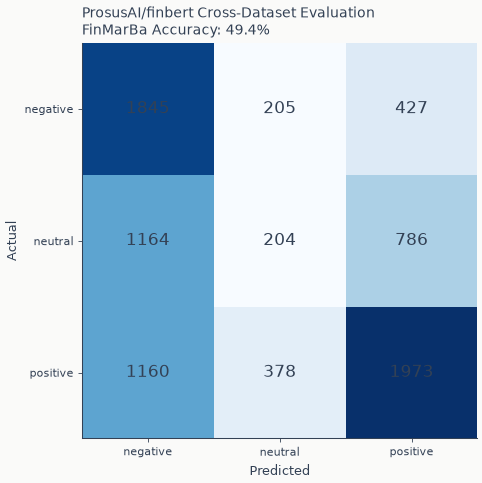

In [9]:
# Confusion matrix for FinMarBa
fig, ax = plt.subplots(figsize=(6, 5))
labels = ["negative", "neutral", "positive"]

cm = confusion_matrix(true_labels, predictions)
im = ax.imshow(cm, cmap="Blues")

# Add annotations
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=12)

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"ProsusAI/finbert Cross-Dataset Evaluation\nFinMarBa Accuracy: {accuracy:.1%}")

plt.tight_layout()
plt.show()

## Key Takeaways

### Distribution Shift Explained
- **Same labels**: Both datasets use positive/negative/neutral
- **Different distributions**: Financial PhraseBank has carefully curated sentences;
  FinMarBa has market-reaction-based labels on headlines
- **Performance gap**: The difference reveals distribution shift, NOT label mismatch

### Why This Matters
1. **Same labels ≠ same distribution**: Text style, length, and vocabulary differ
2. **Domain adaptation limits**: Models trained on one corpus may not generalize
3. **Market-based labels**: FinMarBa labels reflect actual market reactions, not
   human annotations—a different notion of "sentiment"

### Implications for Practitioners
- Always evaluate on held-out data from different sources when possible
- Distribution shift is common when applying pre-trained models to new data
- Consider fine-tuning on your target domain for best results

In [10]:
# Structured output
print("=" * 70)
print("KEY INSIGHTS")
print("=" * 70)
print("\nDataset: FinMarBa")
print(f"Samples: {len(df)}")
print("\nFinBERT Performance (ProsusAI/finbert, zero-shot):")
print(f"  Accuracy:   {accuracy:.1%}")
print(f"  F1 (macro): {f1:.3f}")
print(
    "\nReference for context (not measured in this notebook): "
    "Araci (2019) reports ~87% accuracy / ~0.85 macro F1 on Financial "
    "PhraseBank held-out test."
)

# Save results
output_dir = get_chapter_dir(10) / "output" / "finbert_cross_dataset"
output_dir.mkdir(parents=True, exist_ok=True)
results_file = output_dir / "results.md"
with open(results_file, "w") as f:
    f.write("# FinBERT Cross-Dataset Evaluation Results\n\n")
    f.write("## Performance on FinMarBa (Out-of-Sample)\n\n")
    f.write(f"- **Accuracy**: {accuracy:.1%}\n")
    f.write(f"- **F1 (macro)**: {f1:.3f}\n")
    f.write(f"- **Samples**: {len(df):,}\n\n")
    f.write("## Reference for context (not measured in this notebook)\n\n")
    f.write(
        "Araci (2019) reports ~87% accuracy / ~0.85 macro F1 for "
        "ProsusAI/finbert on the held-out Financial PhraseBank test split.\n"
    )

print(f"\nResults saved to: {results_file}")

KEY INSIGHTS

Dataset: FinMarBa
Samples: 8142

FinBERT Performance (ProsusAI/finbert, zero-shot):
  Accuracy:   49.4%
  F1 (macro): 0.428

Reference for context (not measured in this notebook): Araci (2019) reports ~87% accuracy / ~0.85 macro F1 on Financial PhraseBank held-out test.

Results saved to: 10_text_feature_engineering/output/finbert_cross_dataset/results.md
